In [2]:
### Notebook compares d.paint c-mods and d.paint non-c-mods, including:
### > Running filtering of c-mods and non-c-mods
### > Running univariate statistical analyses (Fig 2a, Extended Data Fig 1)
### > Running ML model and feature importance analysis (Fig 2b, 2c)

In [3]:
import ast
import math
import pandas as pd
import numpy as np
import re
from rdkit import Chem, rdBase
import matplotlib.pyplot as plt
import seaborn as sns
import dataframe_image as dfi
from rdkit.Chem import Descriptors, rdMolDescriptors, MACCSkeys
from rdkit.Chem import FilterCatalog
from rdkit.Chem import AllChem, Draw
from rdkit.Chem.Draw import rdMolDraw2D
from rdkit.Chem.Draw import IPythonConsole
from umap import UMAP
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    average_precision_score,
    precision_recall_curve,
)
from sklearn.utils import resample
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.model_selection import StratifiedKFold
from scipy.stats import ks_2samp, mannwhitneyu
from scipy.stats import chi2_contingency, fisher_exact

In [17]:
rdBase.DisableLog("rdApp.*")

In [18]:
sns.set_style("whitegrid")

In [19]:
### Load and filter compounds

In [87]:
#Load dataset of c-mods from d.paint 20 screen
cmods_df = pd.read_csv("./data/dpaint20_cmods.csv")
cmods_df["chemformer"] = cmods_df["chemformer"].apply(ast.literal_eval)
cmods_df["Set"] = "C-mod"

In [67]:
#Load dataset of "FDA library" compounds, a subset of which was used for the d.paint 20 screen
non_cmods_df = pd.read_csv("./data/updated_fda.csv")
non_cmods_df["chemformer"] = non_cmods_df["chemformer"].apply(ast.literal_eval)
non_cmods_df["Set"] = "Non c-mod"

In [68]:
#Remove d.paint c-mods from full FDA library compound list
non_cmods_df = non_cmods_df[
    ~non_cmods_df["Molecule Name"].isin(cmods_df["compound_id"].tolist())
].copy()

In [69]:
#Load CD-CODE c-mods dataset
cd_code_cmods_df = pd.read_csv("./data/cdcode_cmods.csv")

In [70]:
#Remove CD-Code c-mods from FDA library compound list
non_cmods_df = non_cmods_df[
    ~non_cmods_df["canon_smiles"].isin(cd_code_cmods_df["canon_smiles"].tolist())
].copy()

In [71]:
#Load list of all compounds used in d.paint 20 screen
dpaint20_cmpds_df = pd.read_excel(
    "./data/dpaint20_cmpds_and_cmods.xlsx",
    sheet_name="cmpds",
)

In [72]:
#Limit non-c-mods dataset ("FDA library compounds") only to compounds included in the d.paint 20 screen
non_cmods_df = non_cmods_df[non_cmods_df["Molecule Name"].isin(dpaint20_cmpds_df["compound"])].copy()

In [75]:
#Check no overlap between c-mod and non-c-mod dfs
inter = len(
    set(non_cmods_df["Molecule Name"].tolist()).intersection(
        set(cmods_df["compound_id"].tolist())
    )
)

assert inter == 0, "Intersection between FDA and FDA c-mod"

In [76]:
#Function to calculate chemical descriptors

def calc_mol_desc(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    def safe_div(num, denom):
        return float(num) / float(denom) if denom else 0.0
    
    num_heavy_atoms = Descriptors.HeavyAtomCount(mol)
    num_aromatic_atoms = sum(atom.GetIsAromatic() for atom in mol.GetAtoms())
    num_ring_atoms = sum(atom.IsInRing() for atom in mol.GetAtoms())
    valence_e = Descriptors.NumValenceElectrons(mol)
    hbd = Descriptors.NumHDonors(mol)
    hba = Descriptors.NumHAcceptors(mol)
    num_rotatable_bonds = Descriptors.NumRotatableBonds(mol)
    
    return {
        "QED": Descriptors.qed(mol),
        "LogP": Descriptors.MolLogP(mol),
        "MW": Descriptors.ExactMolWt(mol),
        "# of valence electrons": Descriptors.NumValenceElectrons(mol),
        "# of rings": Descriptors.RingCount(mol),
#        "# of heavy atoms": Descriptors.HeavyAtomCount(mol),
        "HBD": Descriptors.NumHDonors(mol),
        "HBA": Descriptors.NumHAcceptors(mol),
        "# of rotatable bonds": num_rotatable_bonds,
        "TPSA": Descriptors.TPSA(mol),
        "# of aromatic rings": rdMolDescriptors.CalcNumAromaticRings(mol),
        "ratio rotatable bonds to atoms": safe_div(num_rotatable_bonds,num_heavy_atoms),
        "fraction atoms in aromatic rings": safe_div(num_aromatic_atoms,num_heavy_atoms), 
        "fraction atoms in rings": safe_div(num_ring_atoms,num_heavy_atoms),
        "ratio valence electrons to atoms": safe_div(valence_e,num_heavy_atoms),
        "fraction HBD": safe_div(hbd,num_heavy_atoms),
        "fraction HBA": safe_div(hba,num_heavy_atoms),
    }

In [77]:
#Calculate chemical descriptors for c-mods
mol_desc = cmods_df["canon_smiles"].apply(calc_mol_desc)
mol_desc = mol_desc.apply(pd.Series)
desc_cols = mol_desc.columns
cmods_df = cmods_df.join(mol_desc)

In [78]:
#Calculate chemical descriptors for non-c-mods
mol_desc = non_cmods_df["canon_smiles"].apply(calc_mol_desc)
mol_desc = mol_desc.apply(pd.Series)
non_cmods_df = non_cmods_df.join(mol_desc)

In [79]:
#Function to build PAINS catalog for filtering
def build_pains_catalog():
    pains_params = FilterCatalog.FilterCatalogParams()
    pains_sets = [
        FilterCatalog.FilterCatalogParams.FilterCatalogs.PAINS_A,
        FilterCatalog.FilterCatalogParams.FilterCatalogs.PAINS_B,
#        FilterCatalog.FilterCatalogParams.FilterCatalogs.PAINS_C, << Only use High (A) and Medium (B) filters for now
    ]
    for p in pains_sets:
        pains_params.AddCatalog(p)
    return FilterCatalog.FilterCatalog(pains_params)

pains_catalog = build_pains_catalog()

In [80]:
#Function to remove any null smiles
def smiles_to_mol(smiles):
    if pd.isna(smiles):
        return None
    return Chem.MolFromSmiles(smiles)

In [81]:
#Function to run PAINS filtering using catalog generated
def is_pains(mol):
    return pains_catalog.HasMatch(mol)

In [82]:
#Apply to c-mods
cmods_df["rdkit_mol"] = cmods_df["SMILES"].apply(smiles_to_mol)

cmods_df["is_pains"] = cmods_df["rdkit_mol"].apply(is_pains)

cmods_filtered_df = cmods_df[~cmods_df["is_pains"]].copy()

In [83]:
#Apply to non-c-mods
non_cmods_df["rdkit_mol"] = non_cmods_df["SMILES"].apply(smiles_to_mol)

non_cmods_df["is_pains"] = non_cmods_df["rdkit_mol"].apply(is_pains)

non_cmods_filtered_df = non_cmods_df[~non_cmods_df["is_pains"]].copy()

In [84]:
#Remove any c-mods >1000Da
cmods_filtered_df = cmods_filtered_df[cmods_filtered_df["MW"] < 1000]

In [85]:
#Remove any non-c-mods >1000Da
non_cmods_filtered_df = non_cmods_filtered_df[non_cmods_filtered_df["MW"] < 1000]

In [86]:
#Check number of compounds in each set, before and after filtering
pd.DataFrame(
    {
        "C-mod": [len(cmods_df)],
        "Filtered c-mod": [len(cmods_filtered_df)],
        "Non c-mod": [len(non_cmods_df)],
        "Filtered non-c-mod": [len(non_cmods_filtered_df)],
    },
    index=["Number of compounds"],
).style.set_table_styles(
    [
        {"selector": "td", "props": [("border", "1px solid black")]},
        {"selector": "th", "props": [("border", "1px solid black")]},
        {"selector": "th.col_heading", "props": [("background-color", "lightgray")]},
        {"selector": "th.row_heading", "props": [("background-color", "lightgray")]},
        {"selector": "caption", "props": [("font-weight", "bold")]},
    ],
).format(
    "{:,}"
)

,C-mod,Filtered c-mod,Non c-mod,Filtered non-c-mod
Number of compounds,587,512,"3,788","3,447"


In [39]:
#Check overlap between c-mods and non-c-mods again
if len(
    set(cmods_filtered_df["SMILES"].tolist()).intersection(
        set(non_cmods_filtered_df["SMILES"].tolist())
    )
):
    print("There is overlap between c-mod and non-c-mod datasets")

In [40]:
### Run univariate statistics

In [41]:
#Create df with both sets together for univariate statistics
temp_df = pd.concat([cmods_filtered_df, non_cmods_filtered_df], ignore_index=True)

/tmp/ipykernel_1580/2846754739.py:107: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 1, 0.95])


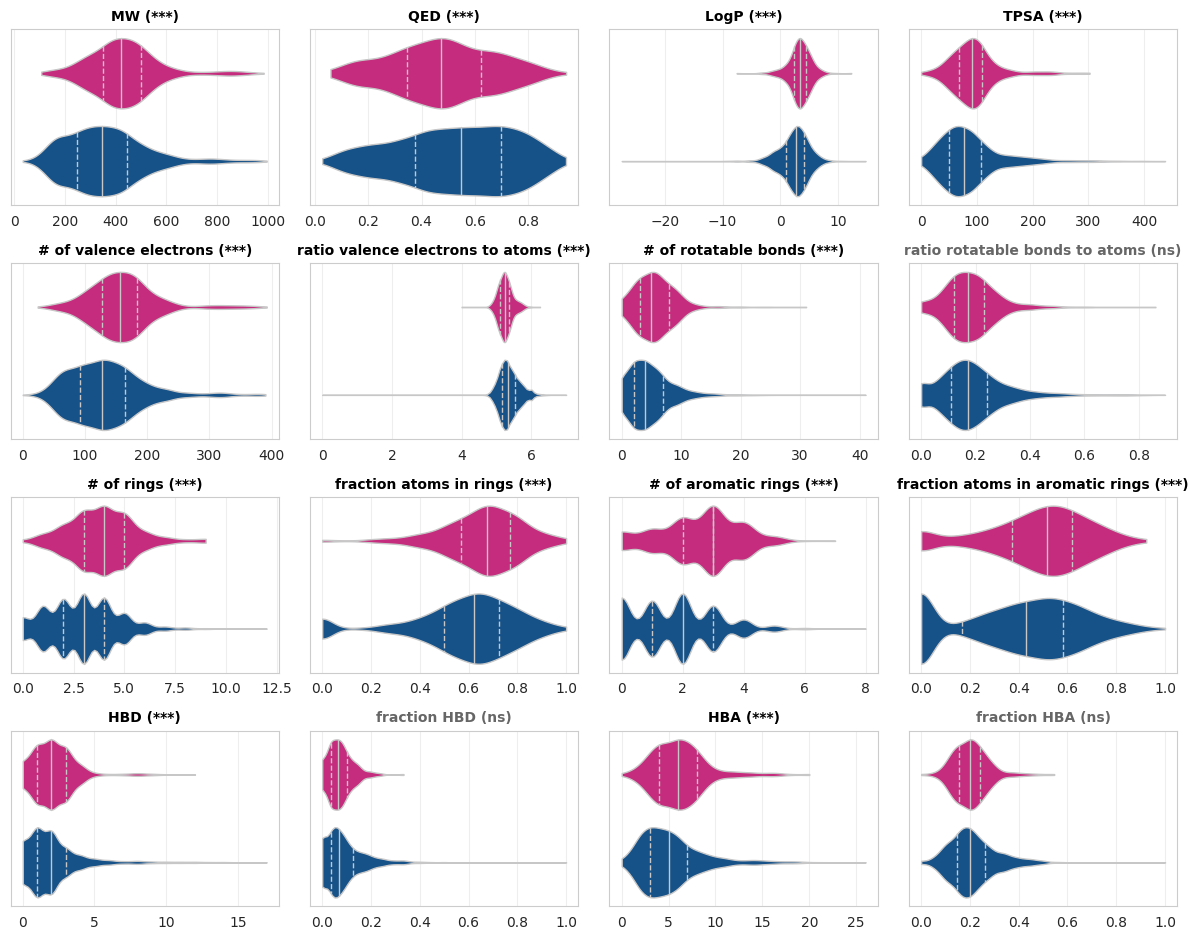

In [48]:
# Produce violin plots for each chemical descriptor
properties = [
    "MW",
    "QED",
    "LogP",
    "TPSA",
    "# of valence electrons",
    "ratio valence electrons to atoms",
    "# of rotatable bonds",
    "ratio rotatable bonds to atoms",
    "# of rings",
    "fraction atoms in rings",
    "# of aromatic rings",
    "fraction atoms in aromatic rings",
    "HBD",
    "fraction HBD",
    "HBA",
    "fraction HBA",
]

plot_palette = {
    "C-mod": "#DE137E",
    "Non c-mod": "#03529B",
}

non_sig = {
    "ratio rotatable bonds to atoms",
    "fraction HBD",
    "fraction HBA",
}

grid_color = "#eeeeee"
median_color = "#c7c7c7"
quartile_color = "#c7c7c7"
edge_color = "#c7c7c7"

fig, axes = plt.subplots(4, 4, figsize=(12, 10), constrained_layout=True)

for ax, prop in zip(axes.flatten(), properties):
    sns.violinplot(
        data=temp_df,
        x=prop,
        y="Set",
        hue="Set",
        order=["C-mod", "Non c-mod"],
        hue_order=["C-mod", "Non c-mod"],
        palette=plot_palette,
        inner="quartile",
        cut=0,
        linewidth=1,
        ax=ax
    )

    # significance label in title
    if prop in non_sig:
        title_text = f"{prop} (ns)"
        title_color = "0.4"
    else:
        title_text = f"{prop} (***)"
        title_color = "black"

    ax.set_title(title_text, fontsize=10, fontweight="bold", color=title_color)
    ax.set_xlabel("")
    ax.set_ylabel("")

    # remove row labels and tick marks
    ax.set_yticklabels([])
    ax.tick_params(axis="y", length=0)

    # keep faint vertical gridlines
    ax.xaxis.grid(True, color=grid_color, linewidth=0.8)
    ax.set_axisbelow(True)

    # style quartile/median lines
    # for each violin, seaborn adds 3 lines: lower quartile, median, upper quartile
    for i, line in enumerate(ax.lines):
        if i % 3 == 1:   # median
            line.set_color(median_color)
            line.set_linestyle("-")
        else:            # quartiles
            line.set_color(quartile_color)
            line.set_linestyle("--")

    # style violin borders
    for collection in ax.collections:
        try:
            collection.set_edgecolor(edge_color)
            collection.set_linewidth(1.0)
        except Exception:
            pass

handles, labels = axes[0, 0].get_legend_handles_labels()

for ax in axes.flatten():
    leg = ax.get_legend()
    if leg is not None:
        leg.remove()

if handles:
    fig.legend(
        handles, labels,
        loc="upper center",
        ncols=2,
        bbox_to_anchor=(0.5, 0.98)
    )

plt.tight_layout(rect=[0, 0, 1, 0.95])
#plt.savefig("./figures/dpaint_cmod_vs_non_cmod_filtered_violinplot.png")
plt.show()

In [49]:
#Build summary statistics table
desc_df = pd.concat(
    [
        cmods_filtered_df[desc_cols].describe().T,
        non_cmods_filtered_df[desc_cols].describe().T,
    ],
    keys=["C-mod", "Non c-mod"],
).sort_index(level=[1, 0], ascending=[True, False])

In [50]:
#Show summary statistics table
def style_borders(df):
    styles = []
    for i in range(1, len(df)):
        if i % 2 == 0:
            styles.append(
                {
                    "selector": f"tr:nth-child({i+1})",
                    "props": [
                        ("border-top", "3px solid black"),
                    ],
                }
            )
    styles += [
        {"selector": f"tr:nth-child(1)", "props": [("border-top", "3px solid black")]},
        {
            "selector": f"tr:nth-child({len(df)})",
            "props": [("border-bottom", "3px solid black")],
        },
        {
            "selector": "th",
            "props": [
                ("border", "1px solid black"),
                ("border-left", "3px solid black"),
                ("border-right", "3px solid black"),
            ],
        },
        {
            "selector": "td",
            "props": [
                ("border-left", "3px solid black"),
                ("border-right", "3px solid black"),
            ],
        },
        {"selector": "th.col_heading", "props": [("background-color", "lightgray")]},
        {"selector": "th.row_heading", "props": [("background-color", "lightgray")]},
    ]
    return styles


desc_df.style.set_table_styles(style_borders(desc_df)).format("{:,.2f}")

,,count,mean,std,min,25%,50%,75%,max
Non c-mod,# of aromatic rings,"3,447.00",1.72,1.36,0.00,1.00,2.00,3.00,8.00
C-mod,# of aromatic rings,512.00,2.55,1.30,0.00,2.00,3.00,3.00,7.00
Non c-mod,# of rings,"3,447.00",2.93,1.71,0.00,2.00,3.00,4.00,12.00
C-mod,# of rings,512.00,3.89,1.60,0.00,3.00,4.00,5.00,9.00
Non c-mod,# of rotatable bonds,"3,447.00",4.86,3.82,0.00,2.00,4.00,7.00,41.00
C-mod,# of rotatable bonds,512.00,5.70,3.58,0.00,3.00,5.00,8.00,31.00
Non c-mod,# of valence electrons,"3,447.00",134.58,61.23,0.00,92.00,128.00,164.00,390.00
C-mod,# of valence electrons,512.00,160.68,54.87,24.00,128.00,156.00,184.00,392.00
Non c-mod,HBA,"3,447.00",5.30,3.52,0.00,3.00,5.00,7.00,26.00
C-mod,HBA,512.00,6.19,2.99,0.00,4.00,6.00,8.00,20.00


In [45]:
#Save summary statistics table to csv
#desc_df.to_csv("dpaint_descriptors.csv", index=True)

In [63]:
#Filter to descriptor columns only
cmods_desc_df = cmods_filtered_df[desc_cols]
non_cmods_desc_df = non_cmods_filtered_df[desc_cols]

In [64]:
#Handling of null and infinity values
cmods_desc_df = pd.DataFrame(cmods_desc_df)
cmods_desc_df.fillna(0.0, inplace=True)
cmods_desc_df.replace([np.inf, -np.inf], 0.0, inplace=True)
cmods_desc_df = cmods_desc_df.clip(
    lower=np.finfo(np.float32).min, upper=np.finfo(np.float32).max
)

non_cmods_desc_df = pd.DataFrame(non_cmods_desc_df)
non_cmods_desc_df.fillna(0.0, inplace=True)
non_cmods_desc_df.replace([np.inf, -np.inf], 0.0, inplace=True)
non_cmods_desc_df = non_cmods_desc_df.clip(
    lower=np.finfo(np.float32).min, upper=np.finfo(np.float32).max
)

In [65]:
#Run and multiple-comparison correct Mann-Whitney U and KS tests
def bh_qvalues(pvals: np.ndarray) -> np.ndarray:
    """Benjamini–Hochberg FDR adjusted p-values (q-values)."""
    pvals = np.asarray(pvals, dtype=float)
    n = pvals.size
    if n == 0:
        return pvals

    order = np.argsort(pvals)
    ranked = pvals[order]
    ranks = np.arange(1, n + 1)

    q = ranked * n / ranks
    # enforce monotonicity from largest to smallest
    q = np.minimum.accumulate(q[::-1])[::-1]
    q = np.clip(q, 0.0, 1.0)

    out = np.empty_like(q)
    out[order] = q
    return out

rows = []

for desc in non_cmods_desc_df.columns:
    ks_stat, ks_p = ks_2samp(cmods_desc_df[desc].to_list(),
                             non_cmods_desc_df[desc].to_list(),
                             alternative="two-sided")
    u_stat, u_p = mannwhitneyu(cmods_desc_df[desc].to_list(),
                               non_cmods_desc_df[desc].to_list(),
                               alternative="two-sided")

    rows.append({
        "Descriptor": desc,
        "Kolmogorov–Smirnov (KS) Test (p-value)": ks_p,
        "Kolmogorov–Smirnov (KS) Test": ks_stat,
        "Mann–Whitney U Test (p-value)": u_p,
        "Mann–Whitney U Test": u_stat,
    })

c_vs_f_df = pd.DataFrame(rows).set_index("Descriptor")

# BH correction separately for KS and MWU families
c_vs_f_df["Kolmogorov–Smirnov (KS) Test (q-value, BH)"] = bh_qvalues(
    c_vs_f_df["Kolmogorov–Smirnov (KS) Test (p-value)"].to_numpy()
)
c_vs_f_df["Mann–Whitney U Test (q-value, BH)"] = bh_qvalues(
    c_vs_f_df["Mann–Whitney U Test (p-value)"].to_numpy()
)


In [62]:
#Save statistics as xlsx output
#with pd.ExcelWriter("dpaint_ks_u_mcc_filtered.xlsx", engine="xlsxwriter") as writer:
#    c_vs_f_df.to_excel(writer, sheet_name="dpaint cmod vs non")

In [46]:
### ML model

In [51]:
# Function to run RF model
def run_cv(X, y, n_splits):
    metric_dfs = []
    importances = []

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=21)

    for ind, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
        X_train, X_valid = X.iloc[train_idx].copy(), X.iloc[valid_idx].copy()
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        clf = RandomForestClassifier(
        random_state=21,
        n_estimators=200,
        max_depth=4,
        #max_features="log2",
        #min_samples_leaf=40,
        n_jobs=-1
        )
        clf.fit(X_train, y_train)
        importances.append(clf.feature_importances_)

        train_preds = clf.predict(X_train)
        valid_preds = clf.predict(X_valid)

        metric_dfs.append(
            pd.DataFrame(
                {
                    "Metric": ["Accuracy"] * 2,
                    "Score": [
                        accuracy_score(y_train, train_preds),
                        accuracy_score(y_valid, valid_preds),
                    ],
                    "Set": ["Training", "Validation"],
                }
            )
        )

        metric_dfs.append(
            pd.DataFrame(
                {
                    "Metric": ["Precision"] * 2,
                    "Score": [
                        precision_score(y_train, train_preds),
                        precision_score(y_valid, valid_preds),
                    ],
                    "Set": ["Training", "Validation"],
                }
            )
        )

        metric_dfs.append(
            pd.DataFrame(
                {
                    "Metric": ["Recall"] * 2,
                    "Score": [
                        recall_score(y_train, train_preds),
                        recall_score(y_valid, valid_preds),
                    ],
                    "Set": ["Training", "Validation"],
                }
            )
        )
        metric_dfs.append(
            pd.DataFrame(
                {
                    "Metric": ["F1"] * 2,
                    "Score": [
                        f1_score(y_train, train_preds),
                        f1_score(y_valid, valid_preds),
                    ],
                    "Set": ["Training", "Validation"],
                }
            )
        )
        metric_dfs.append(
            pd.DataFrame(
                {
                    "Metric": ["AUROC"] * 2,
                    "Score": [
                        roc_auc_score(y_train, clf.predict_proba(X_train)[:, 1]),
                        roc_auc_score(y_valid, clf.predict_proba(X_valid)[:, 1]),
                    ],
                    "Set": ["Training", "Validation"],
                }
            )
        )
        metric_dfs.append(
            pd.DataFrame(
                {
                    "Metric": ["AUPRC"] * 2,
                    "Score": [
                        average_precision_score(
                            y_train, clf.predict_proba(X_train)[:, 1]
                        ),
                        average_precision_score(
                            y_valid, clf.predict_proba(X_valid)[:, 1]
                        ),
                    ],
                    "Set": ["Training", "Validation"],
                }
            )
        )

    return pd.concat(metric_dfs), importances

In [52]:
#Run RF model across all cross-validation folds and downsampling seeds
random_seeds = [23, 43, 63, 83, 103, 123, 143, 163, 183, 203]

all_results = []
all_importances = []

for seed in random_seeds:
    temp_df_run = temp_df.copy()
    
    df_fda_downsampled = resample(
        temp_df_run[temp_df_run["Set"] == "Non c-mod"],
        replace=False,
        n_samples=(temp_df_run["Set"] == "C-mod").sum(),
        random_state=seed,
    )

    temp_df_run = pd.concat(
    [df_fda_downsampled, temp_df_run[temp_df_run["Set"] == "C-mod"]],
    ignore_index=True,
    )

    temp_df_run = temp_df_run.sample(frac=1, random_state=21).reset_index(drop=True)

    scaler = StandardScaler()
    scaled_desc = pd.DataFrame(scaler.fit_transform(temp_df_run[desc_cols]), columns=desc_cols)

    fp_df = pd.DataFrame(
    [MACCSkeys.GenMACCSKeys(Chem.MolFromSmiles(smiles)).ToList() for smiles in temp_df_run["canon_smiles"]],
    columns=[f"MACCS_{i}" for i in range(167)],
    )

    features_df = pd.concat([fp_df, scaled_desc], axis=1)
    temp_df_run["label"] = temp_df_run["Set"].map(
        {
            "Non c-mod": 0,
            "C-mod": 1,
        }
    )

    res_df, importances = run_cv(features_df, temp_df_run["label"], 10)

    res_df["random_seed"] = seed
    all_results.append(res_df)

    imp_full = pd.Series(
        np.array(importances).mean(axis=0),
        index=features_df.columns,
        name=seed,
    )
    all_importances.append(imp_full)

final_res_df = pd.concat(all_results, ignore_index=True)
importances_df = pd.concat(all_importances, axis=1).T


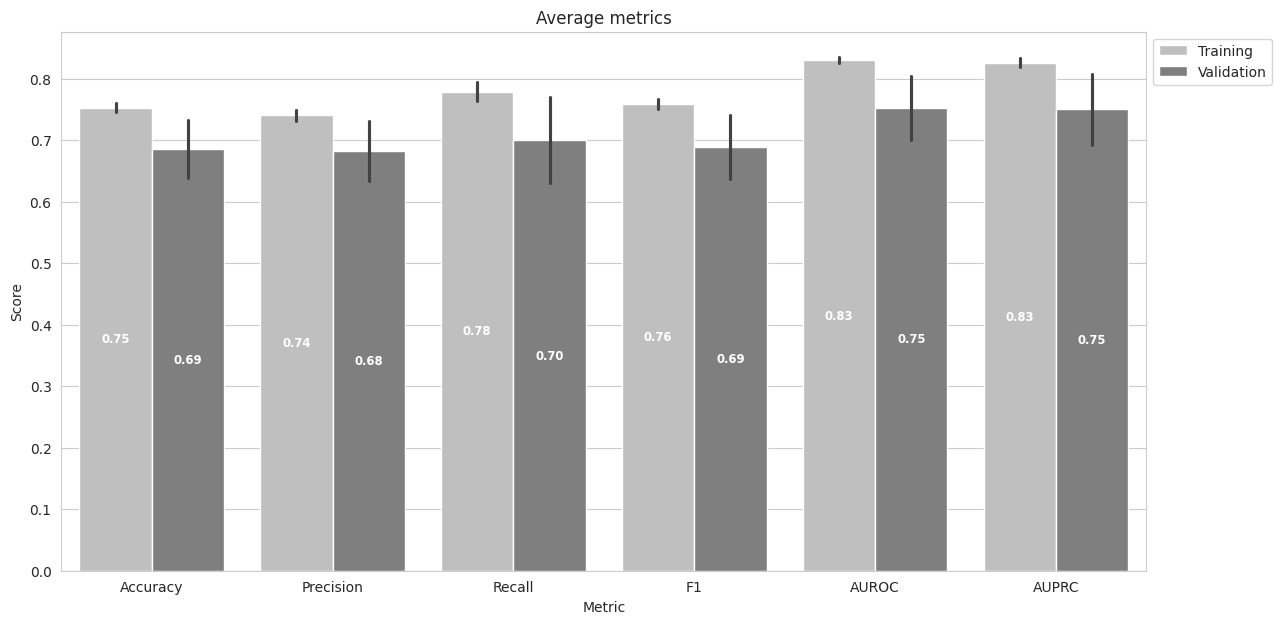

In [53]:
#Plot performance metrics across all cross-validation folds and down-sampling seeds
plt.figure(figsize=(14, 7))

plot_palette = {
    "Training": "#BFBFBF",
    "Validation": "#7F7F7F",
}

ax = sns.barplot(
    final_res_df,
    x="Metric",
    y="Score",
    hue="Set",
    errorbar="sd",
    palette=plot_palette
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        fontsize="small",
        label_type="center",
        color="white",
        weight="bold",
    )

plt.legend(bbox_to_anchor=(1, 1))

plt.title("Average metrics")
#plt.savefig("./figures/dpaint_cmod_vs_fda_both_filtered_model_cv_performance.png")
plt.show()

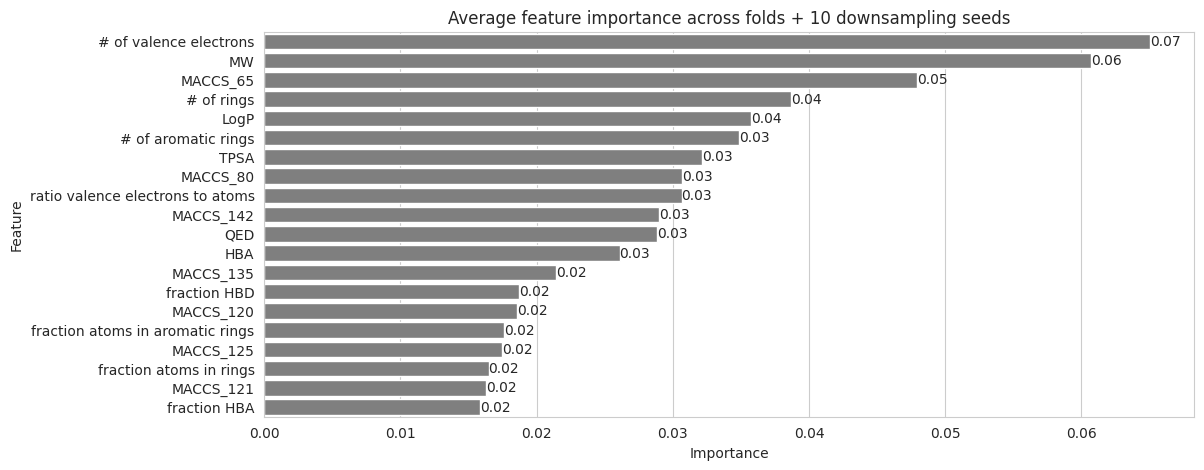

In [55]:
#Calculate feature importance across all cross-validation folds and down-sampling seeds
mean_imp = importances_df.mean(axis=0)

imp = mean_imp.sort_values(ascending=False).head(20)

plt.figure(figsize=(12, 5))

ax = sns.barplot(
    x=imp.values,
    y=imp.index,
    color="#7F7F7F",
)

ax.bar_label(ax.containers[0], fmt="%.2f")

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Average feature importance across folds + 10 downsampling seeds")
#plt.savefig("./figures/dpaint_cmod_vs_fda_both_filtered_model_cv_feature_imp.png")
plt.show()

In [56]:
#Identify SMARTS patterns corresponding to important MACCS fingerprint bits
bits_patt = {"Bit": [], "SMARTS pattern": [], "Comment": []}

for i in imp.index:
    if i.startswith("MACCS_"):
        bits_patt["Bit"].append(i)

        bit_ind = int(i.split("_")[-1])
        patt = MACCSkeys.smartsPatts[bit_ind][0]
        
        bits_patt["SMARTS pattern"].append(patt)
        
        if patt == "?":
            if bit_ind == 166:
                bits_patt["Comment"].append("Fragments; can't be done in SMARTS")
            else:
                bits_patt["Comment"].append("ISOTOPE")
        else:
            bits_patt["Comment"].append("")
            
pd.DataFrame(bits_patt).style.set_table_styles(
    [
        {"selector": "td", "props": [("border", "1px solid black")]},
        {"selector": "th", "props": [("border", "1px solid black")]},
        {"selector": "th.col_heading", "props": [("background-color", "lightgray")]},
        {"selector": "th.row_heading", "props": [("background-color", "lightgray")]},
        {"selector": "caption", "props": [("font-weight", "bold")]},
    ],
).hide()

Bit,SMARTS pattern,Comment
MACCS_65,c:n,
MACCS_80,[#7]~*~*~*~[#7],
MACCS_142,[#7],
MACCS_135,[#7]!:*:*,
MACCS_120,[!#6;R],
MACCS_125,?,ISOTOPE
MACCS_121,[#7;R],
